## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)





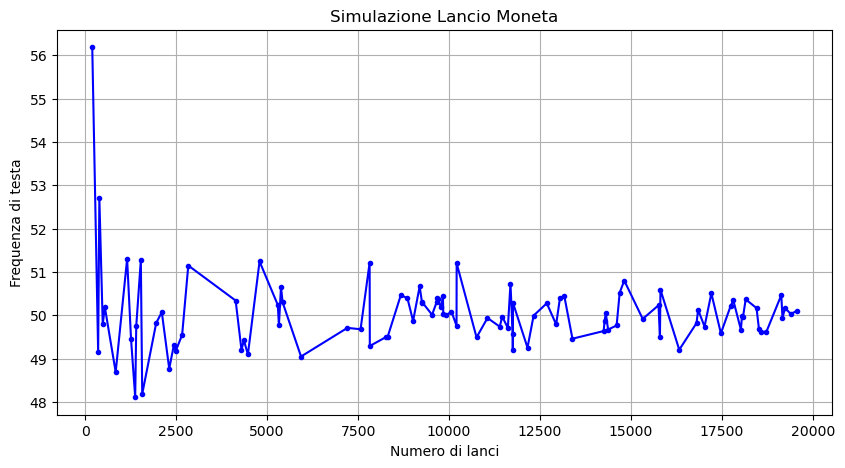

In [1]:
import random
import matplotlib.pyplot as plt
def simulazione_lancio_moneta(lanci):
    if lanci<=0:
        return 0.0
    testa=0
    for x in range(lanci):
        risultato=random.choice(['testa', 'croce'])
        if risultato=='testa':
            testa+=1
    frequenza_percentuale=(testa*100)/lanci
    return frequenza_percentuale
numero_di_lanci=[]
frequenze_testa=[]
for x in range(100):
    lanci=random.randint(10, 20000)
    frequenza=simulazione_lancio_moneta(lanci)
    numero_di_lanci.append(lanci)
    frequenze_testa.append(frequenza)
dati_ordinati = sorted(zip(numero_di_lanci, frequenze_testa))
x_plot, y_plot=zip(*dati_ordinati)
plt.figure(figsize=(10, 5))
plt.plot(x_plot, y_plot, color='blue', marker='o', markersize=3, linestyle='-')
plt.xlabel('Numero di lanci')
plt.ylabel('Frequenza di testa')
plt.title('Simulazione Lancio Moneta')
plt.grid(True)
plt.show()

## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

Dimensioni dataset:(891, 12)


Valori mancanti per colonna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Righe duplicate: 0


Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64


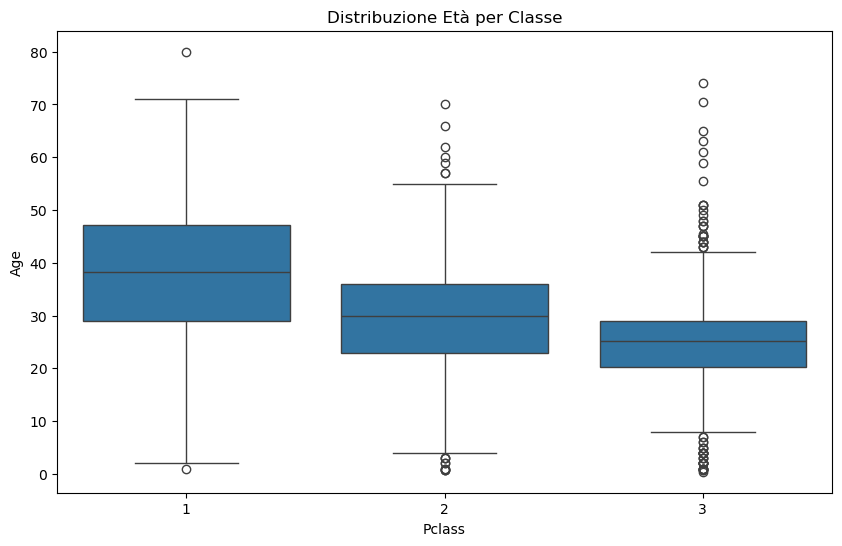

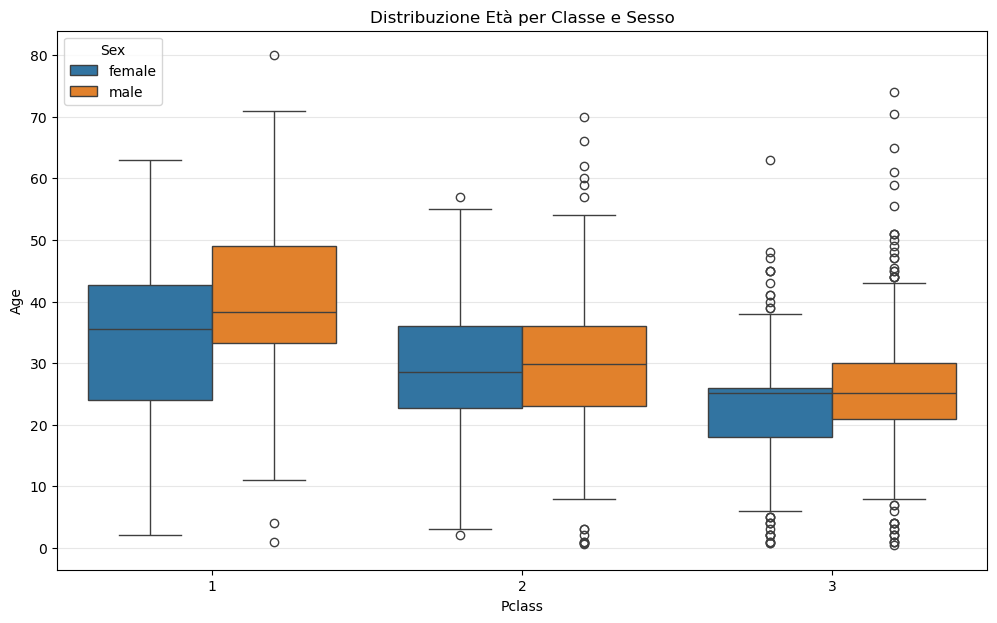

In [2]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(f"Dimensioni dataset:{df.shape}")
print("\n")
print("Valori mancanti per colonna:")
print(df.isnull().sum())
embarked_frequente=df['Embarked'].mode()[0]
df['Embarked']=df['Embarked'].fillna(embarked_frequente)
print("\n")
print(f"Righe duplicate: {df.duplicated().sum()}")
print("\n")
età_media=(df.groupby("Pclass")["Age"].mean())
print(età_media)
df['Age'] = df['Age'].fillna(df.groupby('Pclass')['Age'].transform('mean'))
plt.figure(figsize=(10, 6))
sns.boxplot(x="Pclass", y="Age", data=df)
plt.title("Distribuzione Età per Classe")
plt.figure(figsize=(12, 7))
sns.boxplot(x="Pclass", y="Age", hue="Sex", data=df)
plt.title("Distribuzione Età per Classe e Sesso")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 3. Analisi del Dataset Iris

- Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
- Calcola la lunghezza e la larghezza media dei petali per specie
- Visualizza le dimensioni dei petali per specie (scatterplot)
- Crea una nuova colonna per l'area del petalo e analizzala
- Grafico della distribuzione dell'area del petalo per specie (boxplot)

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


            petal_length  petal_width
species                              
setosa             1.462        0.246
versicolor         4.260        1.326
virginica          5.552        2.026


            count     mean       std   min     25%     50%    75%    max
species                                                                 
setosa       50.0   0.3656  0.181155  0.11  0.2800   0.300   0.42   0.96
versicolor   50.0   5.7204  1.368403  3.30  4.8600   5.615   6.75   8.64
virginica    50.0  11.2962  2.157412  7.50  9.7175  11.445  12.79  15.87


C:\Users\Utente\AppData\Local\Temp\ipykernel_2808\3088438428.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y="area_petalo", palette="viridis")


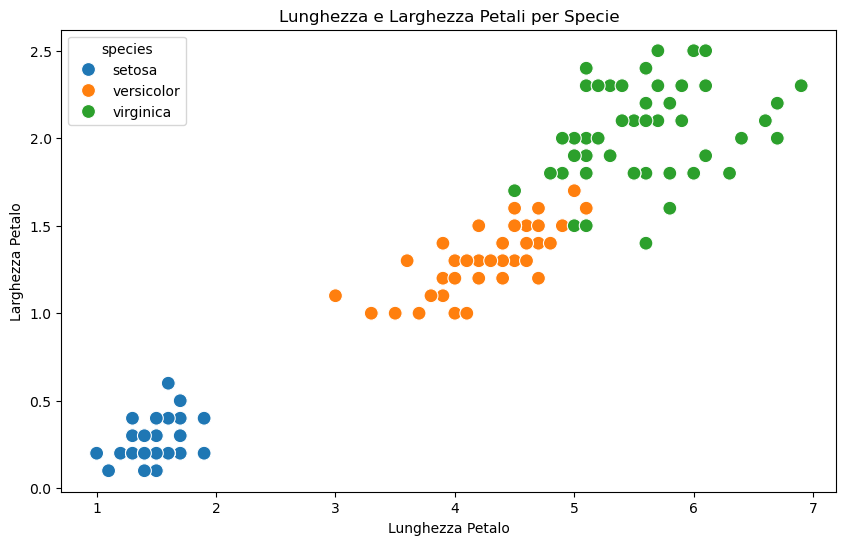

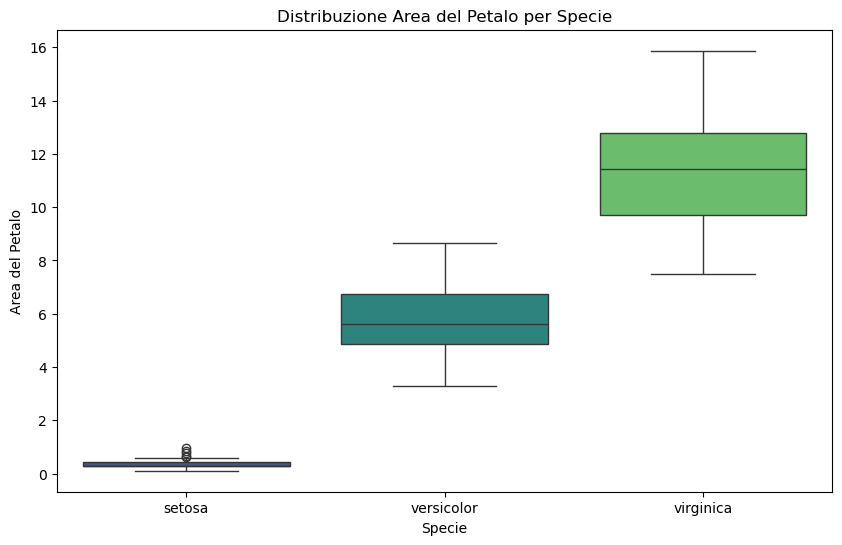

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

print(df["species"].value_counts())
print("\n")
medie = df.groupby("species")[["petal_length", "petal_width"]].mean()
print(medie)
print("\n")
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="petal_length", y="petal_width", hue="species", s=100)
plt.title("Lunghezza e Larghezza Petali per Specie")
plt.xlabel("Lunghezza Petalo")
plt.ylabel("Larghezza Petalo")
df["area_petalo"]=df["petal_length"]*df["petal_width"]
print(df.groupby("species")["area_petalo"].describe())
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="species", y="area_petalo", palette="viridis")
plt.title("Distribuzione Area del Petalo per Specie")
plt.xlabel("Specie")
plt.ylabel("Area del Petalo")
plt.show()